# Top

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pyomo.environ import (
    ConcreteModel,
    TransformationFactory,
    SolverFactory,
    Var,
    Param,
    value,
    assert_optimal_termination,
    units as pyunits,
)
from pyomo.network import Arc
from pyomo.util.check_units import assert_units_consistent
from idaes.models.unit_models import ValveFunctionType, Valve
from idaes.core import FlowsheetBlock, EnergyBalanceType
from idaes.core.util import scaling as iscale
from idaes.core.solvers import get_solver
from idaes.core.util.model_statistics import degrees_of_freedom
from idaes.core.util.model_diagnostics import DiagnosticsToolbox
from idaes.core.util.dyn_utils import copy_values_at_time, copy_non_time_indexed_values
from idaes.core.util.initialization import initialize_by_time_element, propagate_state
import idaes.logger as idaeslog
import logging

from idaes.models_extra.tvsa_1d.unit_models.fixed_bed_1D import FixedBed1D

from idaes.models.properties.modular_properties.base.generic_property import (
    GenericParameterBlock,
)
from idaes.models_extra.power_generation.properties.natural_gas_PR import (
    EosType,
    get_prop,
)

# 30% relative humidity

In [2]:
# Get Model Function
def get_model(dynamic=True, time_set=None, nstep=None, init=True):
    """
    dynamic: boolean flag for dynamic model
    time_set: list for time points to initialize th model (in seconds)
    nstep: number of time discretization points
    init: don't think this is used
    """
    # create upper level concrete model block
    m = ConcreteModel()
    m.dynamic = dynamic
    if time_set is None:
        time_set = [0, 30, 60, 2000]
    if nstep is None:
        nstep = 30
    # ====================

    # create flowsheet block
    if m.dynamic:
        m.fs = FlowsheetBlock(dynamic=True, time_set=time_set, time_units=pyunits.s)
    else:
        m.fs = FlowsheetBlock(dynamic=False)
    # ====================

    # create properties package
    gas_species = {"CO2", "H2O", "N2"}
    # modify the bounds of pressure, default lower bound is 5e4
    configuration = get_prop(gas_species, ["Vap"], EosType.IDEAL)
    pres_bounds = (1e4, 1e5, 1e6, pyunits.Pa)
    configuration["state_bounds"]["pressure"] = pres_bounds
    m.fs.gas_properties = GenericParameterBlock(
        **configuration,
        doc="gas property",
    )

    m.fs.gas_properties.set_default_scaling("enth_mol_phase", 1e-3)
    m.fs.gas_properties.set_default_scaling("pressure", 1e-5)
    m.fs.gas_properties.set_default_scaling("temperature", 1e-2)
    m.fs.gas_properties.set_default_scaling("flow_mol", 1e4)
    m.fs.gas_properties.set_default_scaling("flow_mol_phase", 1e4)
    m.fs.gas_properties.set_default_scaling("_energy_density_term", 1e-4)

    _mf_scale = {
        "CO2": 50,
        "H2O": 10,
        "N2": 1,
    }
    for comp, s in _mf_scale.items():
        m.fs.gas_properties.set_default_scaling("mole_frac_comp", s, index=comp)
        m.fs.gas_properties.set_default_scaling(
            "mole_frac_phase_comp", s, index=("Vap", comp)
        )
        m.fs.gas_properties.set_default_scaling(
            "flow_mol_phase_comp", s * 1e4, index=("Vap", comp)
        )
    # ====================

    # create fixed bed model block
    nxfe = 20
    x_nfe_list = [0, 1]
    m.fs.FB = FixedBed1D(
        dynamic=dynamic,
        finite_elements=nxfe,
        length_domain_set=x_nfe_list,
        transformation_method="dae.finite_difference",
        energy_balance_type=EnergyBalanceType.enthalpyTotal,
        pressure_drop_type="ergun_correlation",
        property_package=m.fs.gas_properties,
        adsorbent="Lewatit",
        coadsorption_isotherm="Mechanistic",  # "Stampi-Bombelli", #"WADST","Mechanistic"
        adsorbent_shape="particle",
    )
    # ====================

    # create valves
    m.fs.Inlet_Valve = Valve(
        dynamic=False,
        valve_function_callback=ValveFunctionType.linear,
        property_package=m.fs.gas_properties,
    )

    m.fs.Outlet_Valve = Valve(
        dynamic=False,
        valve_function_callback=ValveFunctionType.linear,
        property_package=m.fs.gas_properties,
    )

    m.fs.inlet_valve2bed = Arc(
        source=m.fs.Inlet_Valve.outlet, destination=m.fs.FB.gas_inlet
    )

    m.fs.bed2outlet_valve = Arc(
        source=m.fs.FB.gas_outlet, destination=m.fs.Outlet_Valve.inlet
    )
    # ====================

    # Call arcs and discretizer for time domain
    TransformationFactory("network.expand_arcs").apply_to(m.fs)

    if m.dynamic:
        m.discretizer = TransformationFactory("dae.finite_difference")
        m.discretizer.apply_to(m, nfe=nstep, wrt=m.fs.time, scheme="BACKWARD")
    # ====================
    
    # adjust model parameters/variables
    m.fs.FB.kf["CO2"] = 0.005  # original 0.003
    m.fs.FB.kf["H2O"] = 0.0143  # original 0.0086
    m.fs.FB.bed_diameter.fix(0.0067)
    m.fs.FB.wall_diameter.fix(0.0068)
    m.fs.FB.bed_height.fix(0.01074)
    m.fs.FB.particle_dia.fix(5.2e-4)
    m.fs.FB.heat_transfer_coeff_gas_wall = 353.0  # original 35.3
    m.fs.FB.heat_transfer_coeff_fluid_wall = (
        2200  # original 220, use a large value to mimic fixed wall temperature
    )
    m.fs.FB.fluid_temperature.fix(298.15)

    flow_mol_gas = 3e-5  # Reported by the paper by Young et al. (2021)
    m.fs.Inlet_Valve.Cv.fix(
        0.000003
    )
    m.fs.Inlet_Valve.valve_opening.fix(0.9)
    m.fs.Inlet_Valve.inlet.flow_mol.fix(flow_mol_gas)
    m.fs.Inlet_Valve.inlet.temperature.fix(298.15)
    m.fs.Inlet_Valve.inlet.pressure.fix(
        102000
    )
    m.fs.Inlet_Valve.inlet.mole_frac_comp[:, "CO2"].fix(0.000001)
    m.fs.Inlet_Valve.inlet.mole_frac_comp[:, "H2O"].fix(0.0001)
    m.fs.Inlet_Valve.inlet.mole_frac_comp[:, "N2"].fix(0.999899)

    m.fs.Outlet_Valve.Cv.fix(
        0.000003
    )
    m.fs.Outlet_Valve.outlet.pressure.fix(101325)
    # ====================

    # scaling 
    iscale.set_scaling_factor(m.fs.FB.gas_phase.heat, 1e-2)
    iscale.set_scaling_factor(m.fs.FB.gas_phase.area, 1e4)
    iscale.set_scaling_factor(m.fs.Inlet_Valve.control_volume.work, 1e-3)
    iscale.set_scaling_factor(m.fs.Outlet_Valve.control_volume.work, 1e-3)
    iscale.calculate_scaling_factors(m)
    # ====================

    # initialize flowsheet model (only initialize non-dynamic model)
    if m.dynamic:
        m.fs.FB.set_initial_condition()
        m.fs.Inlet_Valve.valve_opening.fix()
        m.fs.Outlet_Valve.valve_opening.fix()
        m.fs.Inlet_Valve.inlet.flow_mol.unfix()
    else:
        solver = get_solver("ipopt_v2")
        # initialize by fixing flow rate and changing inlet and outlet valve openings
        m.fs.Inlet_Valve.initialize()
        propagate_state(m.fs.inlet_valve2bed)
        m.fs.FB.initialize(outlvl=4)
        propagate_state(m.fs.bed2outlet_valve)
        m.fs.Outlet_Valve.valve_opening.unfix()
        m.fs.Outlet_Valve.initialize()
        print("flow_mol=", value(m.fs.Inlet_Valve.inlet.flow_mol[0]))
        print(
            "Cvs of inlet and outlet valves=",
            value(m.fs.Inlet_Valve.Cv),
            value(m.fs.Outlet_Valve.Cv),
        )
        print(
            "openings of inlet and outlet valves=",
            value(m.fs.Inlet_Valve.valve_opening[0]),
            value(m.fs.Outlet_Valve.valve_opening[0]),
        )
        print(
            "bed inlet and outlet pressures = ",
            value(m.fs.FB.gas_inlet.pressure[0]),
            value(m.fs.FB.gas_outlet.pressure[0]),
        )
        # unfix flow rate but fix two valve openings, calculate flow rate
        m.fs.Inlet_Valve.inlet.flow_mol.unfix()
        m.fs.Inlet_Valve.valve_opening.fix(0.9)
        m.fs.Outlet_Valve.valve_opening.fix(0.43067)
        solver.solve(m, tee=True)
        print("flow_mol=", value(m.fs.Inlet_Valve.inlet.flow_mol[0]))
        print(
            "Cvs of inlet and outlet valves=",
            value(m.fs.Inlet_Valve.Cv),
            value(m.fs.Outlet_Valve.Cv),
        )
        print(
            "openings of inlet and outlet valves=",
            value(m.fs.Inlet_Valve.valve_opening[0]),
            value(m.fs.Outlet_Valve.valve_opening[0]),
        )
        print(
            "bed inlet and outlet pressures = ",
            value(m.fs.FB.gas_inlet.pressure[0]),
            value(m.fs.FB.gas_outlet.pressure[0]),
        )
        assert_units_consistent(m)
        print("assert_units_consistent called")
    return m

In [3]:
# create a steady-state model (just used to initialize dynamic model)
m_ss = get_model(dynamic=False)

2024-12-18 11:19:52 [INFO] idaes.init.fs.Inlet_Valve.control_volume.properties_in: Starting initialization
2024-12-18 11:19:54 [INFO] idaes.init.fs.Inlet_Valve.control_volume.properties_in: Property initialization: optimal - Optimal Solution Found.
2024-12-18 11:19:54 [INFO] idaes.init.fs.Inlet_Valve.control_volume.properties_out: Starting initialization
2024-12-18 11:19:54 [INFO] idaes.init.fs.Inlet_Valve.control_volume.properties_out: Property initialization: optimal - Optimal Solution Found.
2024-12-18 11:19:54 [INFO] idaes.init.fs.Inlet_Valve.control_volume.properties_out: Property package initialization: optimal - Optimal Solution Found.
2024-12-18 11:19:54 [INFO] idaes.init.fs.Inlet_Valve: Initialization Complete: optimal - Optimal Solution Found
2024-12-18 11:19:54 [INFO] idaes.init.fs.FB: Initialize Thermophysical Properties
2024-12-18 11:19:54 [INFO] idaes.init.fs.FB.gas_phase.properties: Starting initialization
2024-12-18 11:19:54 [INFO] idaes.init.fs.FB.gas_phase.properties:

In [12]:
m_ss.fs.report()


Flowsheet : fs                                                             Time: 0.0
------------------------------------------------------------------------------------
    Stream Table
                                Units       inlet_valve2bed  bed2outlet_valve
    Total Molar Flowrate     mole / second    3.0000e-05        3.0000e-05   
    Total Mole Fraction N2   dimensionless       0.99990           0.99990   
    Total Mole Fraction H2O  dimensionless    0.00010000        0.00010000   
    Total Mole Fraction CO2  dimensionless    1.0000e-06        1.0000e-06   
    Temperature                     kelvin        298.15            298.15   
    Pressure                        pascal    1.0188e+05        1.0186e+05   


In [5]:
m_dyn = get_model(dynamic=True)

In [14]:
m_dyn.fs.report()


Flowsheet : fs                                                             Time: 0.0
------------------------------------------------------------------------------------
    Stream Table
                                Units       inlet_valve2bed  bed2outlet_valve
    Total Molar Flowrate     mole / second        8000.0            8000.0   
    Total Mole Fraction N2   dimensionless       0.33333           0.33333   
    Total Mole Fraction H2O  dimensionless       0.33333           0.33333   
    Total Mole Fraction CO2  dimensionless       0.33333           0.33333   
    Temperature                     kelvin        500.00            500.00   
    Pressure                        pascal    1.0000e+05        1.0000e+05   


In [15]:
# initialize dynamic model
copy_non_time_indexed_values(
    m_dyn.fs, m_ss.fs, copy_fixed=True, outlvl=idaeslog.ERROR
)
for t in m_dyn.fs.time:
    copy_values_at_time(
        m_dyn.fs, m_ss.fs, t, 0.0, copy_fixed=True, outlvl=idaeslog.ERROR
    )
optarg = {
    "max_iter": 50,
    "nlp_scaling_method": "user-scaling",
    # "halt_on_ampl_error": "yes",
    "linear_solver": "ma27",  # ma57 is default for ipopt_v2, which has convergence issue
}
solver = get_solver("ipopt_v2")
solver.options = optarg
# add disturbance and solve dynamic model
for t in m_dyn.fs.time:
    yco2_1 = 0.01
    yh2o_1 = 0.00938  # 0.01565 at 50% RH
    yn2_1 = 0.98062
    if t > 20:
        m_dyn.fs.Inlet_Valve.inlet.mole_frac_comp[t, "CO2"].fix(yco2_1)
        m_dyn.fs.Inlet_Valve.inlet.mole_frac_comp[t, "H2O"].fix(yh2o_1)
        m_dyn.fs.Inlet_Valve.inlet.mole_frac_comp[t, "N2"].fix(yn2_1)

print(
    "inlet and outlet valve opening at t=0 are",
    value(m_dyn.fs.Inlet_Valve.valve_opening[0]),
    value(m_dyn.fs.Outlet_Valve.valve_opening[0]),
)

inlet and outlet valve opening at t=0 are 0.9 0.43067


In [16]:
# solve model

# solve each time element one by one
# initialize_by_time_element(m_dyn.fs, m_dyn.fs.time, solver=solver, outlvl=4)

results = solver.solve(m_dyn, tee=True)
# write_dynamic_results_to_csv(m_dyn, "Lewatit_1pct_30RH_high_kf_result.csv")

component keys that are not exported as part of the NL file.  Skipping.
keys that are not Var, Constraint, Objective, or the model.  Skipping.
Ipopt 3.13.2: linear_solver=ma27
max_iter=50
nlp_scaling_method=user-scaling
tol=1e-06


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    pu

In [17]:
assert_optimal_termination(results)

In [18]:
dt = DiagnosticsToolbox(m_dyn)

In [19]:
# dt.assert_no_structural_warnings(ignore_unit_consistency=True)
# dt.report_structural_issues(m_dyn)

dt.assert_no_numerical_warnings(ignore_parallel_components=True)
# dt.display_potential_evaluation_errors(ignore_unit_consistency=True)

component keys that are not exported as part of the NL file.  Skipping.
keys that are not Var, Constraint, Objective, or the model.  Skipping.


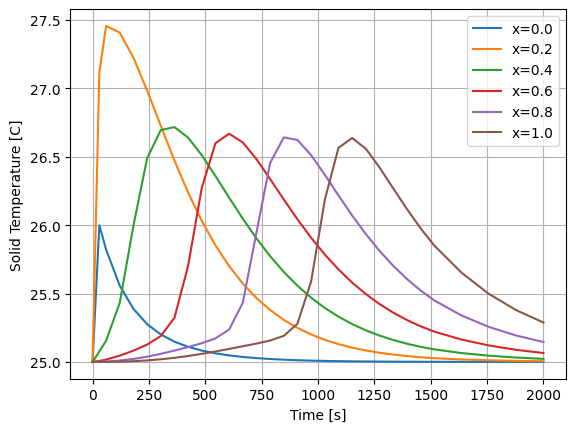

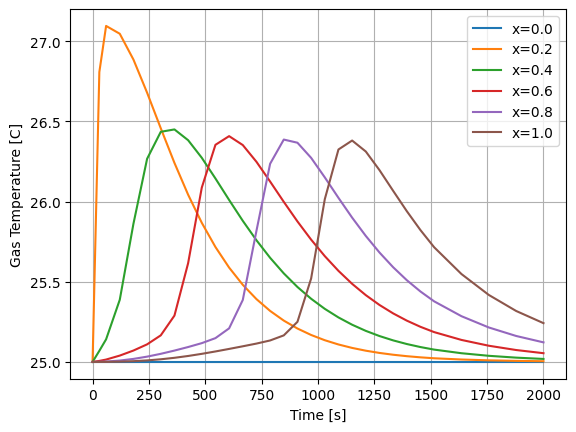

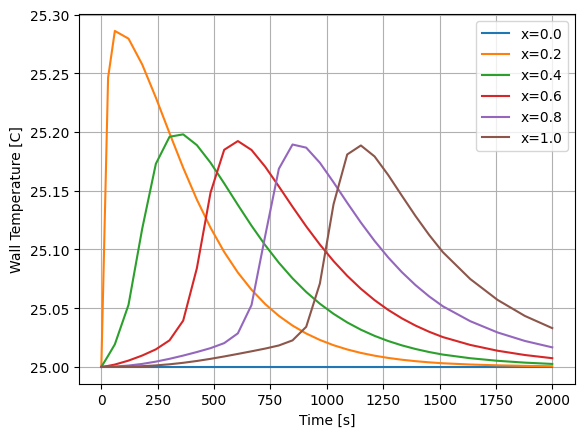

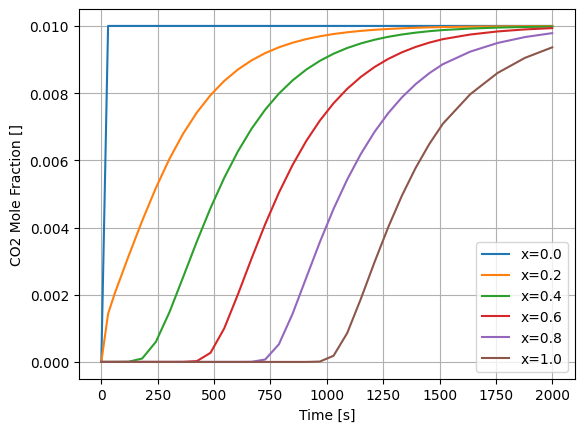

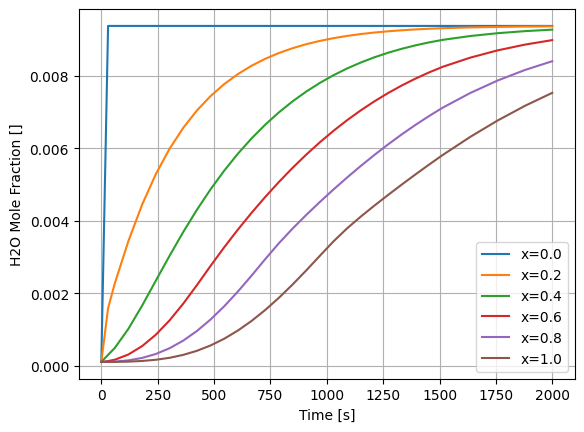

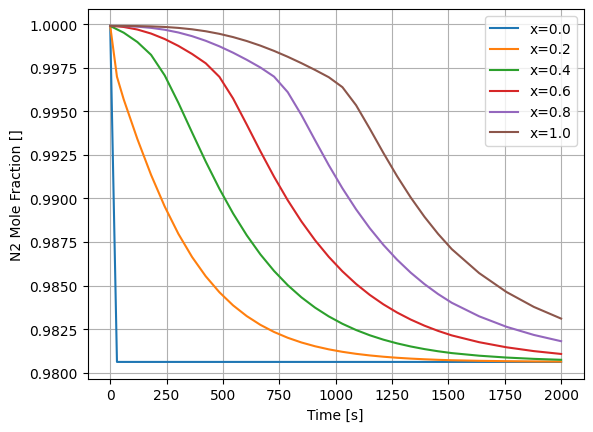

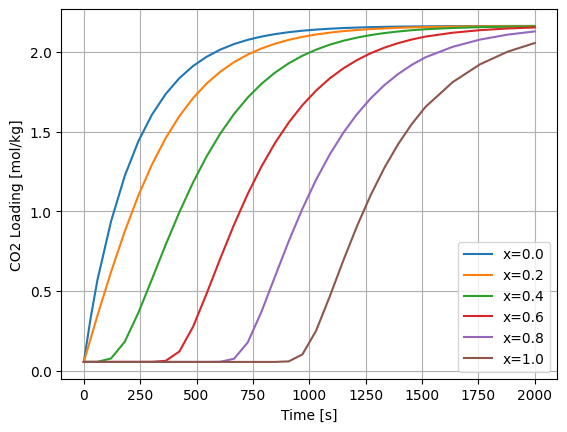

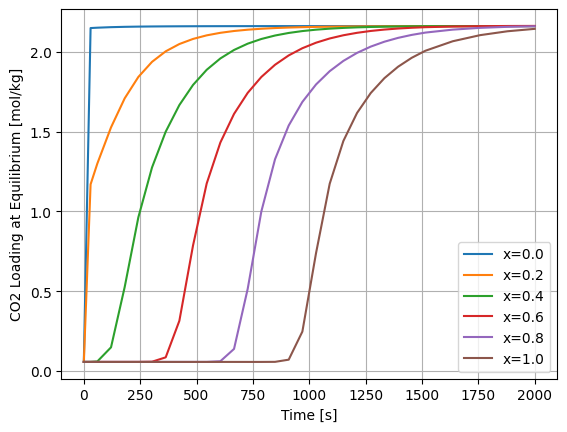

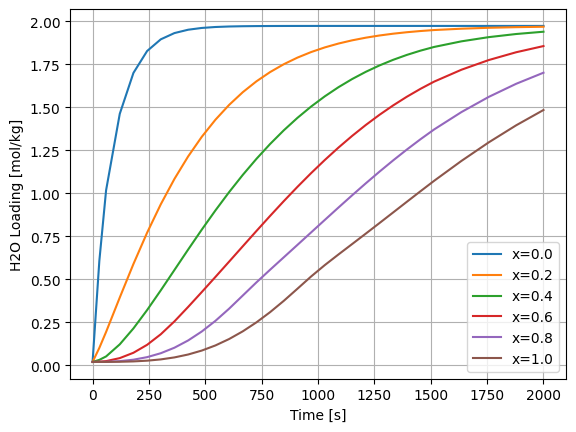

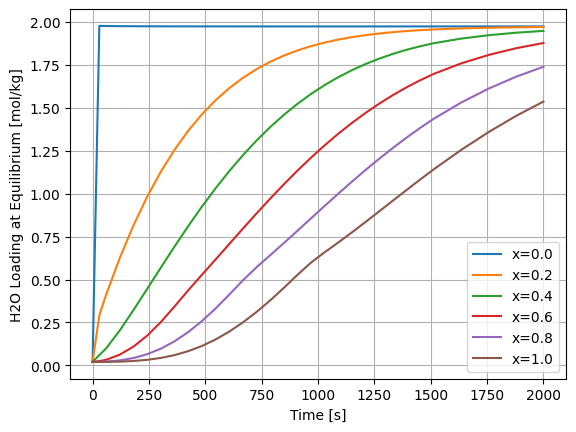

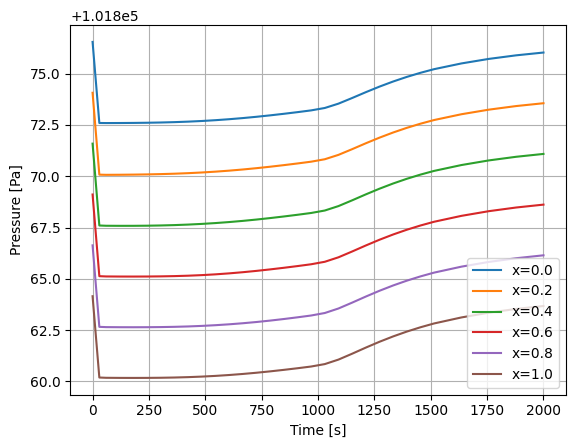

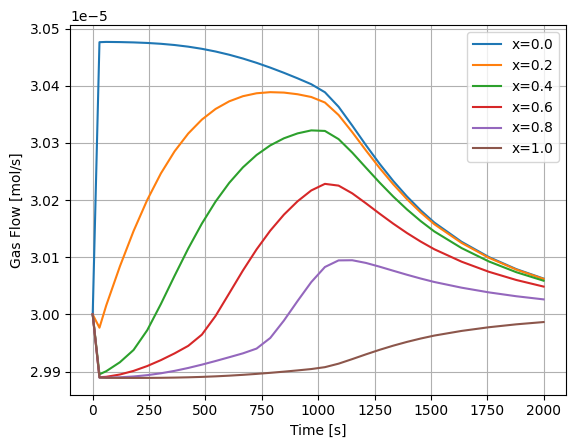

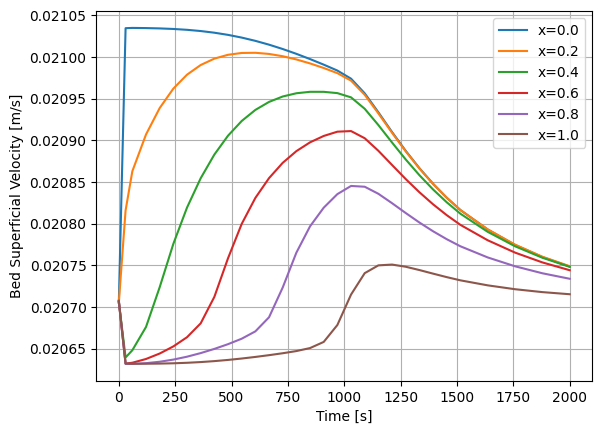

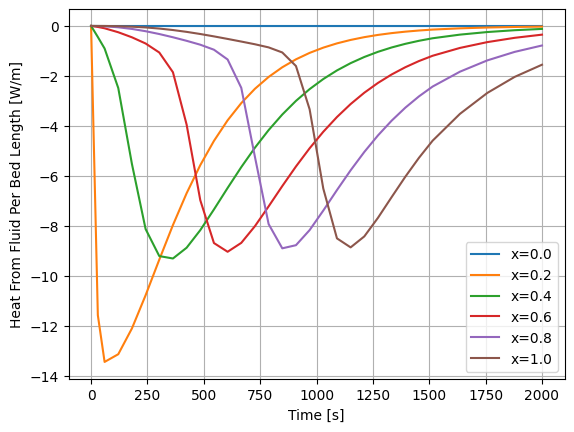

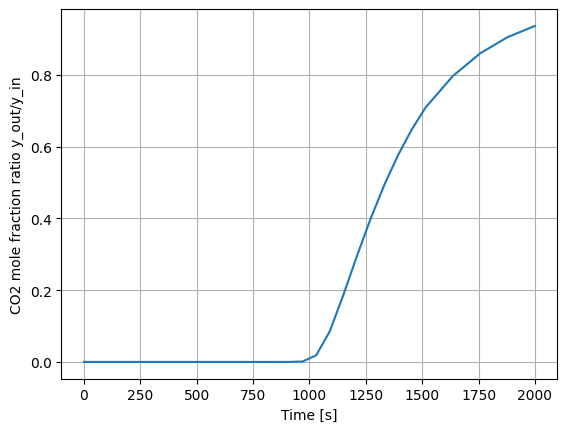

In [20]:
# plot figures
time = []
xlabel = ["x=0.0", "x=0.2", "x=0.4", "x=0.6", "x=0.8", "x=1.0"]
xpoint = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
solid_temp = {}
gas_temp = {}
wall_temp = {}
co2_mf = {}
h2o_mf = {}
n2_mf = {}
loading_co2 = {}
loading_co2_eq = {}
loading_h2o = {}
loading_h2o_eq = {}
pres = {}
flow_mol = {}
vel_sup = {}
heat_fluid = {}
for t in m_dyn.fs.config.time:
    time.append(t)
ix = 0
for x in xpoint:
    y_solid_temp = []
    y_gas_temp = []
    y_wall_temp = []
    y_co2_mf = []
    y_h2o_mf = []
    y_n2_mf = []
    y_loading_co2 = []
    y_loading_co2_eq = []
    y_loading_h2o = []
    y_loading_h2o_eq = []
    y_pres = []
    y_flow_mol = []
    y_vel_sup = []
    y_heat_fluid = []
    for t in m_dyn.fs.config.time:
        y_solid_temp.append(value(m_dyn.fs.FB.solid_temperature[t, x] - 273.15))
        y_gas_temp.append(
            value(m_dyn.fs.FB.gas_phase.properties[t, x].temperature - 273.15)
        )
        y_wall_temp.append(value(m_dyn.fs.FB.wall_temperature[t, x] - 273.15))
        y_co2_mf.append(
            value(m_dyn.fs.FB.gas_phase.properties[t, x].mole_frac_comp["CO2"])
        )
        y_h2o_mf.append(
            value(m_dyn.fs.FB.gas_phase.properties[t, x].mole_frac_comp["H2O"])
        )
        y_n2_mf.append(
            value(m_dyn.fs.FB.gas_phase.properties[t, x].mole_frac_comp["N2"])
        )
        y_loading_co2.append(value(m_dyn.fs.FB.adsorbate_loading[t, x, "CO2"]))
        y_loading_co2_eq.append(
            value(m_dyn.fs.FB.adsorbate_loading_equil[t, x, "CO2"])
        )
        y_loading_h2o.append(value(m_dyn.fs.FB.adsorbate_loading[t, x, "H2O"]))
        y_loading_h2o_eq.append(
            value(m_dyn.fs.FB.adsorbate_loading_equil[t, x, "H2O"])
        )
        y_pres.append(value(m_dyn.fs.FB.gas_phase.properties[t, x].pressure))
        y_flow_mol.append(value(m_dyn.fs.FB.gas_phase.properties[t, x].flow_mol))
        y_vel_sup.append(value(m_dyn.fs.FB.velocity_superficial_gas[t, x]))
        y_heat_fluid.append(value(m_dyn.fs.FB.heat_fluid_to_wall[t, x]))
    solid_temp[xlabel[ix]] = y_solid_temp
    gas_temp[xlabel[ix]] = y_gas_temp
    wall_temp[xlabel[ix]] = y_wall_temp
    co2_mf[xlabel[ix]] = y_co2_mf
    h2o_mf[xlabel[ix]] = y_h2o_mf
    n2_mf[xlabel[ix]] = y_n2_mf
    loading_co2[xlabel[ix]] = y_loading_co2
    loading_co2_eq[xlabel[ix]] = y_loading_co2_eq
    loading_h2o[xlabel[ix]] = y_loading_h2o
    loading_h2o_eq[xlabel[ix]] = y_loading_h2o_eq
    pres[xlabel[ix]] = y_pres
    flow_mol[xlabel[ix]] = y_flow_mol
    vel_sup[xlabel[ix]] = y_vel_sup
    heat_fluid[xlabel[ix]] = y_heat_fluid
    ix += 1

solid_temp_df = pd.DataFrame(solid_temp)
gas_temp_df = pd.DataFrame(gas_temp)
wall_temp_df = pd.DataFrame(wall_temp)
co2_mf_df = pd.DataFrame(co2_mf)
h2o_mf_df = pd.DataFrame(h2o_mf)
n2_mf_df = pd.DataFrame(n2_mf)
loading_co2_df = pd.DataFrame(loading_co2)
loading_co2_eq_df = pd.DataFrame(loading_co2_eq)
loading_h2o_df = pd.DataFrame(loading_h2o)
loading_h2o_eq_df = pd.DataFrame(loading_h2o_eq)
pres_df = pd.DataFrame(pres)
flow_mol_df = pd.DataFrame(flow_mol)
vel_sup_df = pd.DataFrame(vel_sup)
heat_fluid_df = pd.DataFrame(heat_fluid)

# breakthrough curve y_co2_out/y_co2_in
y_co2_ratio = []
for t in m_dyn.fs.config.time:
    y_co2_ratio.append(
        value(m_dyn.fs.FB.gas_phase.properties[t, 1].mole_frac_comp["CO2"] / yco2_1)
    )

plt.figure(1)
plt.plot(time, solid_temp_df, label=xlabel)
plt.legend()
plt.grid()
plt.xlabel("Time [s]")
plt.ylabel("Solid Temperature [C]")
plt.show(block=False)

plt.figure(2)
plt.plot(time, gas_temp_df, label=xlabel)
plt.legend()
plt.grid()
plt.xlabel("Time [s]")
plt.ylabel("Gas Temperature [C]")
plt.show(block=False)

plt.figure(3)
plt.plot(time, wall_temp_df, label=xlabel)
plt.legend()
plt.grid()
plt.xlabel("Time [s]")
plt.ylabel("Wall Temperature [C]")
plt.show(block=False)

plt.figure(4)
plt.plot(time, co2_mf_df, label=xlabel)
plt.legend()
plt.grid()
plt.xlabel("Time [s]")
plt.ylabel("CO2 Mole Fraction []")
plt.show(block=False)

plt.figure(5)
plt.plot(time, h2o_mf_df, label=xlabel)
plt.legend()
plt.grid()
plt.xlabel("Time [s]")
plt.ylabel("H2O Mole Fraction []")
plt.show(block=False)

plt.figure(6)
plt.plot(time, n2_mf_df, label=xlabel)
plt.legend()
plt.grid()
plt.xlabel("Time [s]")
plt.ylabel("N2 Mole Fraction []")
plt.show(block=False)

plt.figure(7)
plt.plot(time, loading_co2_df, label=xlabel)
plt.legend()
plt.grid()
plt.xlabel("Time [s]")
plt.ylabel("CO2 Loading [mol/kg]")
plt.show(block=False)

plt.figure(8)
plt.plot(time, loading_co2_eq_df, label=xlabel)
plt.legend()
plt.grid()
plt.xlabel("Time [s]")
plt.ylabel("CO2 Loading at Equilibrium [mol/kg]")
plt.show(block=False)

plt.figure(9)
plt.plot(time, loading_h2o_df, label=xlabel)
plt.legend()
plt.grid()
plt.xlabel("Time [s]")
plt.ylabel("H2O Loading [mol/kg]")
plt.show(block=False)

plt.figure(10)
plt.plot(time, loading_h2o_eq_df, label=xlabel)
plt.legend()
plt.grid()
plt.xlabel("Time [s]")
plt.ylabel("H2O Loading at Equilibrium [mol/kg]")
plt.show(block=False)

plt.figure(11)
plt.plot(time, pres_df, label=xlabel)
plt.legend()
plt.grid()
plt.xlabel("Time [s]")
plt.ylabel("Pressure [Pa]")
plt.show(block=False)

plt.figure(12)
plt.plot(time, flow_mol_df, label=xlabel)
plt.legend()
plt.grid()
plt.xlabel("Time [s]")
plt.ylabel("Gas Flow [mol/s]")
plt.show(block=False)

plt.figure(13)
plt.plot(time, vel_sup_df, label=xlabel)
plt.legend()
plt.grid()
plt.xlabel("Time [s]")
plt.ylabel("Bed Superficial Velocity [m/s]")
plt.show(block=False)

plt.figure(14)
plt.plot(time, heat_fluid_df, label=xlabel)
plt.legend()
plt.grid()
plt.xlabel("Time [s]")
plt.ylabel("Heat From Fluid Per Bed Length [W/m]")
plt.show(block=False)

plt.figure(15)
plt.plot(time, y_co2_ratio)
plt.grid()
plt.xlabel("Time [s]")
plt.ylabel("CO2 mole fraction ratio y_out/y_in")
plt.show(block=True)